In [5]:
import os
os.getcwd()


'C:\\Users\\kisho'

In [7]:
import os
os.chdir(r"C:\Users\kisho\OneDrive\Desktop\GOLD")


In [8]:
os.getcwd()


'C:\\Users\\kisho\\OneDrive\\Desktop\\GOLD'

In [9]:
from dotenv import load_dotenv
load_dotenv()
print(os.getenv("SNOWFLAKE_ACCOUNT"))


pe11654.central-india.azure


In [11]:
from snowflake.snowpark import Session
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

load_dotenv()

connection_params = {
    "account": os.getenv("SNOWFLAKE_ACCOUNT"),
    "user": os.getenv("SNOWFLAKE_USER"),
    "password": os.getenv("SNOWFLAKE_PASSWORD"),
    "role": "ACCOUNTADMIN",
    "warehouse": "GOLD_WH",
    "database": "GOLD_PROJECT",
    "schema": "PROCESSED"
}

session = Session.builder.configs(connection_params).create()

df = session.table("MASTER_WITH_INDICATORS").to_pandas()

df.head()


,DATE,GOLD_CLOSE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_VOLUME,DXY,CRUDE_OIL,SP500,USDINR,...,MACD_SIGNAL,MACD_HIST,BB_LOWER,BB_MIDDLE,BB_UPPER,ATR,STOCH_K,STOCH_D,MOMENTUM10,ROC
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,0,98.935997,59.23,6705.120117,90.124001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000-08-31,278.299988,274.799988,278.299988,274.799988,0,98.935997,59.23,6705.120117,90.124001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,0,98.935997,59.23,6705.120117,90.124001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,2,98.935997,59.23,6705.120117,90.124001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,0,98.935997,59.23,6705.120117,90.124001,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6334 entries, 0 to 6333
Data columns (total 30 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE         6334 non-null   object 
 1   GOLD_CLOSE   6334 non-null   float64
 2   GOLD_OPEN    6334 non-null   float64
 3   GOLD_HIGH    6334 non-null   float64
 4   GOLD_LOW     6334 non-null   float64
 5   GOLD_VOLUME  6334 non-null   int32  
 6   DXY          6334 non-null   float64
 7   CRUDE_OIL    6334 non-null   float64
 8   SP500        6334 non-null   float64
 9   USDINR       6334 non-null   float64
 10  CPI          6334 non-null   float64
 11  US10Y        6334 non-null   float64
 12  VIX          6334 non-null   float64
 13  SMA10        6334 non-null   float64
 14  SMA20        6334 non-null   float64
 15  SMA50        6334 non-null   float64
 16  EMA12        6334 non-null   float64
 17  EMA26        6334 non-null   float64
 18  RSI14        6334 non-null   float64
 19  MACD  

DATE           0
GOLD_CLOSE     0
GOLD_OPEN      0
GOLD_HIGH      0
GOLD_LOW       0
GOLD_VOLUME    0
DXY            0
CRUDE_OIL      0
SP500          0
USDINR         0
CPI            0
US10Y          0
VIX            0
SMA10          0
SMA20          0
SMA50          0
EMA12          0
EMA26          0
RSI14          0
MACD           0
MACD_SIGNAL    0
MACD_HIST      0
BB_LOWER       0
BB_MIDDLE      0
BB_UPPER       0
ATR            0
STOCH_K        0
STOCH_D        0
MOMENTUM10     0
ROC            0
dtype: int64

In [13]:
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE')


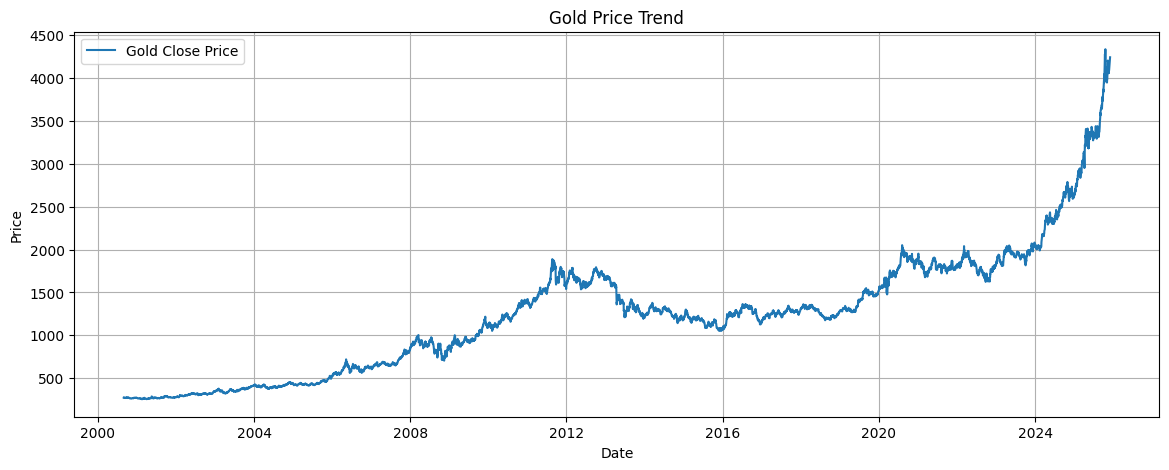

In [14]:
plt.figure(figsize=(14,5))
plt.plot(df['DATE'], df['GOLD_CLOSE'], label='Gold Close Price')
plt.title("Gold Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()


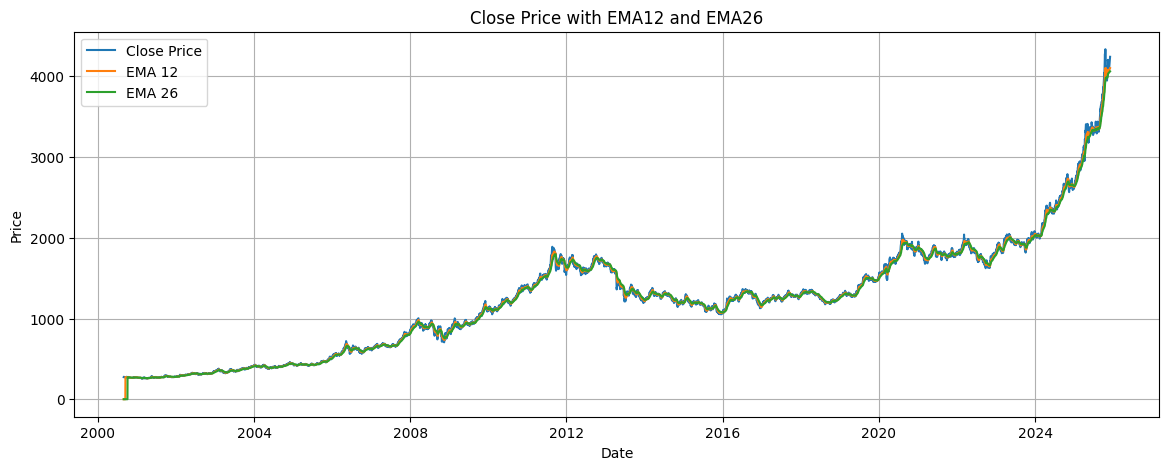

In [17]:
plt.figure(figsize=(14,5))
plt.plot(df['DATE'], df['GOLD_CLOSE'], label='Close Price')
plt.plot(df['DATE'], df['EMA12'], label='EMA 12')
plt.plot(df['DATE'], df['EMA26'], label='EMA 26')
plt.title("Close Price with EMA12 and EMA26")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


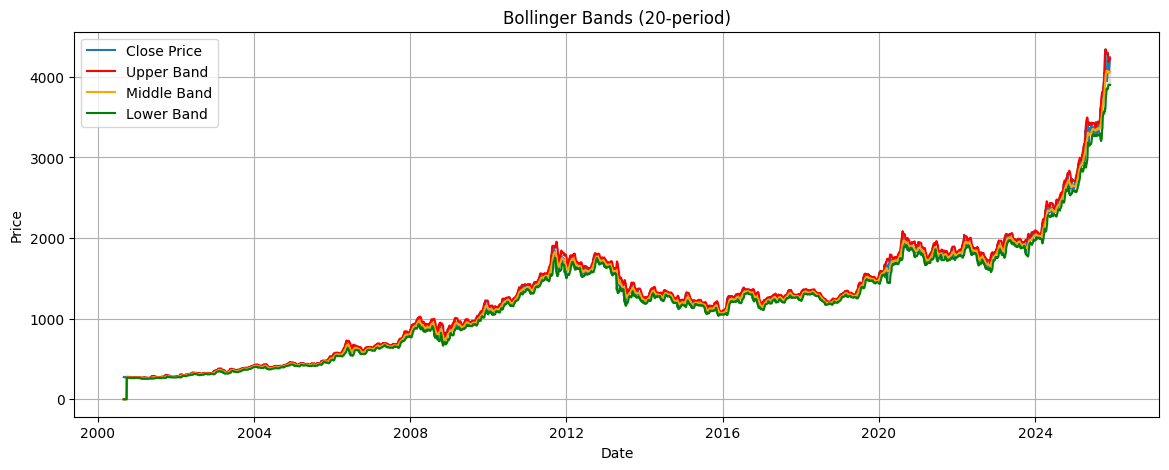

In [19]:
plt.figure(figsize=(14,5))

plt.plot(df['DATE'], df['GOLD_CLOSE'], label='Close Price')

plt.plot(df['DATE'], df['BB_UPPER'], label='Upper Band', color='red')
plt.plot(df['DATE'], df['BB_MIDDLE'], label='Middle Band', color='orange')
plt.plot(df['DATE'], df['BB_LOWER'], label='Lower Band', color='green')

plt.fill_between(
    df['DATE'],
    df['BB_LOWER'],
    df['BB_UPPER'],
    color='gray',
    alpha=0.2
)

plt.title("Bollinger Bands (20-period)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()


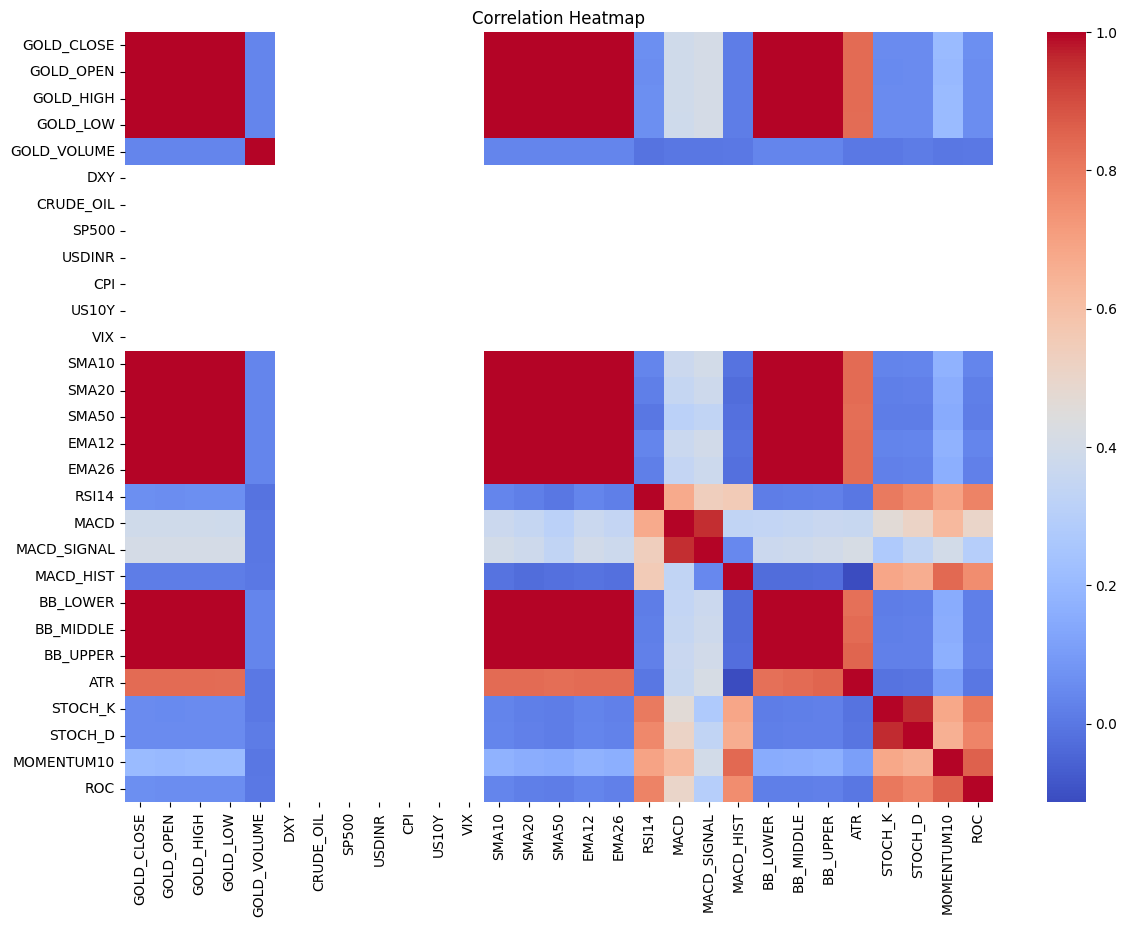

In [20]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


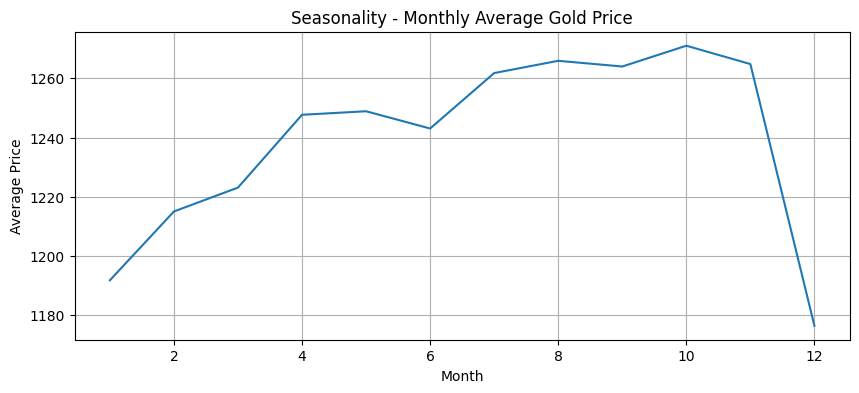

In [21]:
df['month'] = df['DATE'].dt.month
df['year'] = df['DATE'].dt.year

monthly_mean = df.groupby('month')['GOLD_CLOSE'].mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_mean.index, monthly_mean.values)
plt.title("Seasonality - Monthly Average Gold Price")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()


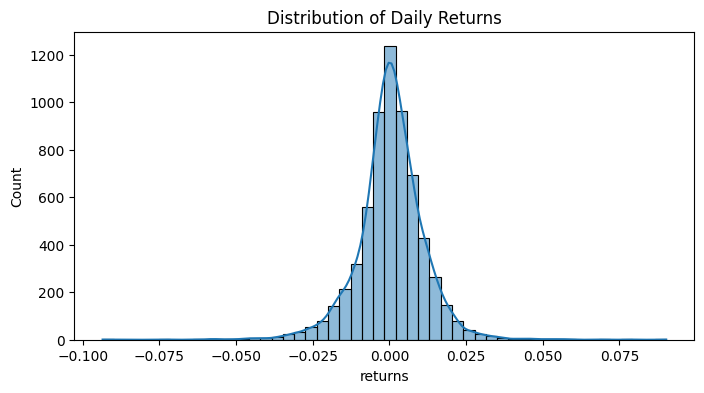

In [22]:
df['returns'] = df['GOLD_CLOSE'].pct_change()

plt.figure(figsize=(8,4))
sns.histplot(df['returns'], kde=True, bins=50)
plt.title("Distribution of Daily Returns")
plt.show()
